## Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
#load upstream results
ss = pd.read_csv('similarity_features.csv')
ner = pd.read_csv('NER.csv')
nli = pd.read_csv('fact_check_results.csv')
tm = pd.read_csv('topic_assignments.csv')

In [3]:
#merge results from the four upstream models
ss = ss.rename(columns={'reference_text': 'reference', 'output_text': 'output'})
result = pd.merge(ss, ner, on = ['reference', 'output'])

result2 = pd.merge(result, nli, on = ['reference', 'output'])

tm = tm.rename(columns = {'Document': 'reference'})
merged = pd.merge(result2, tm)
merged.drop_duplicates(inplace=True)
merged.shape

(7941, 30)

In [4]:
#one hot encode topic ("Name") column
encoded = pd.get_dummies(
    merged,
    columns=['Name'],
    drop_first=True,
    dtype = int
)

encoded = encoded.rename(columns={'Name_Business': 'Business',
                              'Name_Finance': 'Finance',
                              'Name_Health': 'Health',
                              'Name_Law': 'Law',
                              'Name_Science': 'Science',
                              'Name_Technology': 'Technology'})

#change target variable to 0/1
encoded['label'] = encoded['label'].map({'hallucinated': 1, 'factual': 0})

In [5]:
#drop and reorder columns
final = encoded.drop(columns=['ground_truth_label', 'input', 'verdict', 'confidence', 'moderation',
                             'nli_prediction', 'Topic', 'Representation', 'Representative_Docs',
                             'Top_n_words', 'Representative_document'])

final = final[['reference', 'output', 'global_cosine', 'min_window_cosine', 'euclidean_dist', 'length_ratio', 'char_length_diff',
              'Entity Recall', 'Out-Of-Reference Rate', 'Number Overlap', 'contradiction', 'entailment', 'neutral', 
              'Business', 'Finance', 'Health', 'Law', 'Science', 'Technology', 'Probability',
              'label', 'hallucination_type_realized', 'question_type', 'hallucination_type_encouraged']]



In [6]:
#create a df with only the features relevant to model fit 
#(leave out things like question or hallucination type; but may be used in evaluation later)
model_df = final[['global_cosine', 'min_window_cosine', 'euclidean_dist', 'length_ratio', 'char_length_diff', #sentence similarity features
                 'Entity Recall', 'Out-Of-Reference Rate', 'Number Overlap', #NER features 
                 'contradiction', 'entailment', 'neutral', #NLI features
                 'Business', 'Finance', 'Health', 'Law', 'Science', 'Technology', 'Probability', #BERTopic topic modeling features
                 'label']] #target

features = model_df.iloc[:, :-1]
labels = model_df['label']

## Model Fitting

In [7]:
features.head()

,global_cosine,min_window_cosine,euclidean_dist,length_ratio,char_length_diff,Entity Recall,Out-Of-Reference Rate,Number Overlap,contradiction,entailment,neutral,Business,Finance,Health,Law,Science,Technology,Probability
0,0.557387,-0.028328,0.940865,0.192412,596,0.000000,1.000000,1.000000,0.0001,0.0092,0.9907,0,0,1,0,0,0,0.907601
1,0.545204,-0.017767,0.953725,0.295285,284,0.000000,1.000000,0.888889,0.9992,0.0000,0.0007,0,0,0,0,1,0,0.922258
2,0.619412,0.000048,0.872454,0.700730,82,0.500000,0.000000,1.000000,0.0011,0.0000,0.9988,0,0,0,0,0,1,0.876961
3,0.682477,-0.070343,0.796898,1.103837,46,0.200000,0.900000,1.000000,0.0001,0.0001,0.9998,0,0,0,0,0,1,0.913095
4,0.656494,-0.006869,0.828862,0.596154,126,0.333333,0.666667,0.888889,0.0008,0.0002,0.9991,1,0,0,0,0,0,0.900787


In [8]:
#train-test split stratified by label (hallucinated/factual)
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [9]:
one_hot_cols = ['Business', 'Finance', 'Health', 'Law', 'Science', 'Technology']
non_one_hot = ['global_cosine', 'min_window_cosine', 'euclidean_dist', 'length_ratio', 'char_length_diff',
              'Entity Recall', 'Out-Of-Reference Rate', 'Number Overlap', 'contradiction', 'entailment', 'neutral', 'Probability']

preprocessor = ColumnTransformer(
    transformers=[
        ("scale_non_onehot", StandardScaler(), non_one_hot), #use standard scaling on all non encoded variables
        ("passthrough_onehot", "passthrough", one_hot_cols), #leave one hot encoded variables alone
    ]
)

#scale using training set only
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [10]:
#fit GMM on scaled train features
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
gmm.fit(X_train_scaled)
#test_probs = gmm.predict_proba(X_test_scaled)

c:\Users\Carol\miniconda3\envs\spark-env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


## Model Evaluation

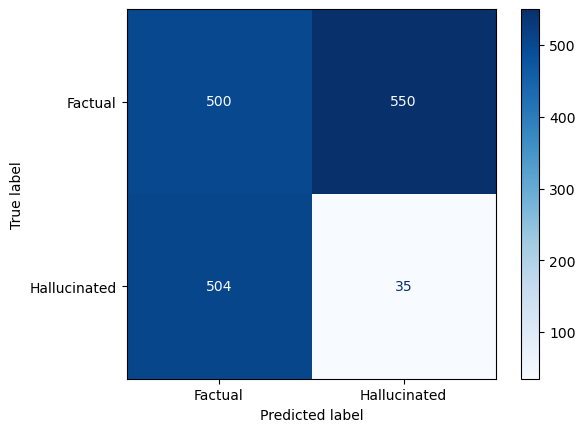

In [11]:
#GMM test results
test_preds = gmm.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

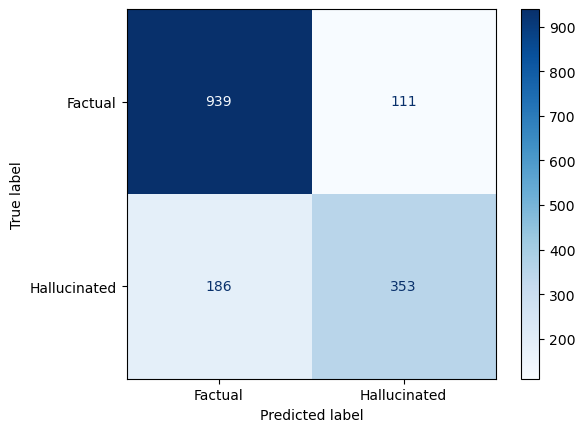

In [12]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train_scaled, y_train)
test_preds = knn.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

In [30]:
from sklearn.tree import DecisionTreeClassifier\

from sklearn.model_selection import GridSearchCV


param_grid = {
    'max_depth': [5, 10, 20, 30, 50, None],
    'min_samples_split': [5, 10, 20, 30, 50],
    'min_samples_leaf': [1, 2, 3, 4, 5, 10, 20, 30, 50]}

dt = DecisionTreeClassifier(random_state=2) #use first value in each list for now

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1)

grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=2)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

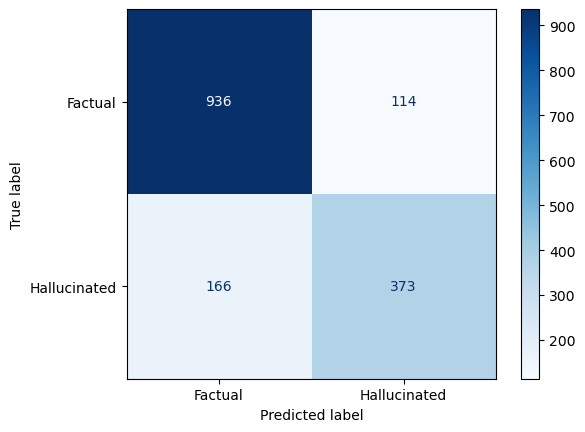

In [31]:
best_dt = grid.best_estimator_

#predict with decision tree
test_preds = best_dt.predict(X_test_scaled)

#confusion matrix for decision tree
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'bootstrap': [True]}

rf = RandomForestClassifier(random_state=2)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1)

grid_rf.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=2)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

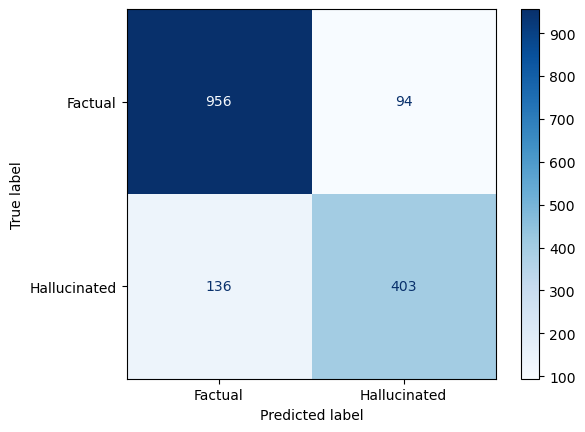

In [28]:
best_rf = grid_rf.best_estimator_

best_rf.fit(X_train_scaled, y_train)
test_preds = best_rf.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

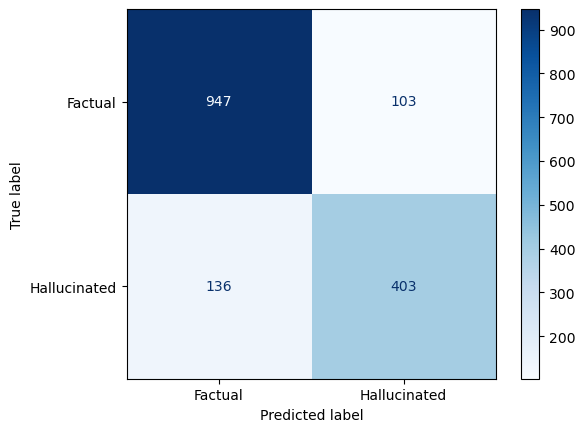

In [29]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rs = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'bootstrap': [True]}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rs,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=2)

random_search.fit(X_train, y_train)

best_rs_random = random_search.best_estimator_

best_rs_random.fit(X_train_scaled, y_train)
test_preds = best_rs_random.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)